In [41]:
from sys import displayhook

from line_loading import calc_line_loads
import sympy as sp
%load_ext autoreload
%autoreload 2
import line_loading
import numpy as np
import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [42]:
z, g, q, ka = sp.symbols("z gamma q k_a")

p = ka*(g * z + q)
print("Pressure:")
display(p)
v = p.integrate(z)
print("Shear force:")
display(v)
m = v.integrate(z)
print("Moment:")
display(m)


Pressure:


k_a*(gamma*z + q)

Shear force:


gamma*k_a*z**2/2 + k_a*q*z

Moment:


gamma*k_a*z**3/6 + k_a*q*z**2/2

In [43]:
m.subs({g:20, ka:0.30, q:5, z:3})

33.7500000000000

In [44]:
w, l, x = sp.symbols('w l x')
shear = w * l / 2 - w * x

moment = shear.integrate(x)
display(moment)

l*w*x/2 - w*x**2/2

In [58]:
span = 3
vals = np.linspace(span,0,30)
yvals = [moment.subs({w:10,l:span, x:y}) for y in vals]
zvals = [shear.subs({w:10,l:span, x:y}) for y in vals]

yv = np.array(yvals,dtype=float)
zv = np.array(zvals,dtype=float)

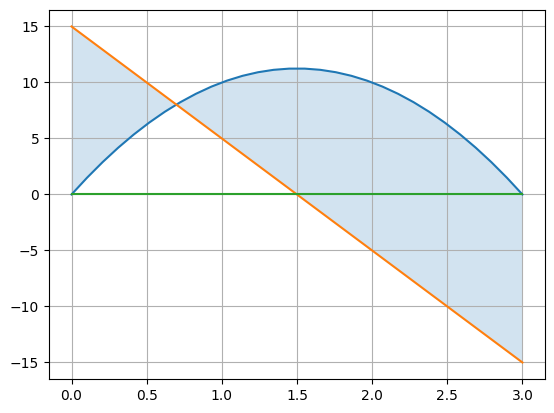

In [64]:
plt.plot(vals, yv)
plt.plot(vals, zv)
plt.fill_between(vals, yv, zv, alpha=0.2)
plt.plot([0,3],[0,0])
plt.grid()
plt.show()